In [15]:
%matplotlib inline

import os, random, time, sys, warnings
sys.path.extend(['/Users/ahmad/software/snaplab_github/neuro_rnn', '/Users/ahmad/software/snaplab_github/neuro_rnn/packages/neurogym'])

import numpy as np
import scipy as sp
import pandas as pd
import torch
from src.utils import get_weight_masks, get_weight_masks_schaefer, get_file_str, get_my_colors

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [16]:
save_figs = True

In [17]:
# directories
# datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
# modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
# # modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/archive/model'
# outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model'
outdir = '/Users/ahmad/data/rutgers/neuro_rnn/results/figs'

# data parameters
dt = 100
batch_size = 32
seq_len_multi = 5
hidden_size = 100

# RNN model and training parameters
rnn_model = 'rnn-tanh'
n_runs = 96
n_epochs = 25000
lr = 0.001

# regularization parameters
reg_type = 'l2'
mask_weights = True

In [18]:
if mask_weights and hidden_size == 50:
    n_io = '9-13' # Default
    # n_io = '9-4' # Cont
elif mask_weights and hidden_size == 100:
    n_io = '14-27' # Default
    # n_io = '14-13' # Cont
elif mask_weights and hidden_size == 200:
    n_io = '31-52' # Default
    # n_io = '31-22' # Cont
else:
    n_io = 'na'

In [19]:
config = {
    'datadir': datadir, 'outdir': outdir,
    'dt': dt, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights, 'hidden_size': hidden_size, # RNN model and training parameters
    'reg_type': reg_type, # regularization parameters
    'n_io': n_io
}

# Model performance

In [42]:
# color_palette = sns.color_palette("Set2")
color_palette = get_my_colors(cat_trio=False, as_list=True)
kernel_types = ['sa_axis', 'euclidean', None]
kernel_labels = ['bioRNNs', 'physRNN', 'mRNNs']

tasks = ['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']
tasks_labels = ['Perceptual Decision Making (DM)', 'Multi Sensory Integration (MultSen DM)', 'Context Decision Making (Ctx DM)']
# tasks = ['MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']
# tasks_labels = ['MultSen DM', 'Ctx DM']
n_tasks = len(tasks)


task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-euclidean
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-None
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-euclidean
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-None
task-ContextDecisionMaking-v0-80-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-ContextDecisionMaking-v0-80-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-euclidean
task-ContextDecisionMaking-v0-80-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-1

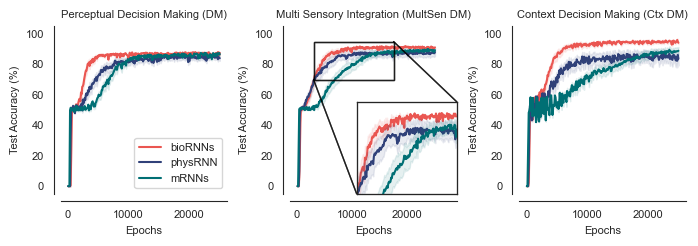

In [21]:
for reg_weight in [0.002,]:
    config['reg_weight'] = reg_weight
    for decision in [400, ]:
        config['decision'] = decision
        timing = {'decision': decision}
        env_kwargs = {'dt': dt, 'timing': timing}
        config['env_kwargs'] = env_kwargs

        f, ax = plt.subplots(1, n_tasks, figsize=(7, 2.5))
        # f, ax = plt.subplots(n_tasks, 1, figsize=(3.5, 3.5))

        for i, task in enumerate(tasks):
            
            # if i > 1: #########################
            #     continue
            
            if task == 'PerceptualDecisionMaking-v0':
                seq_len = 22
            elif task == 'MultiSensoryIntegration-v0':
                seq_len = 11
            elif task == 'ContextDecisionMaking-v0':
                seq_len = 13

            seq_len = seq_len + int((decision - 100) / dt)
            seq_len = seq_len * seq_len_multi

            config['task'] = task
            config['seq_len'] = seq_len

            for j, kernel_type in enumerate(kernel_types):
                config['kernel_type'] = kernel_type

                # load data
                file_str = get_file_str(config)
                print(file_str)
                try:
                    log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
                    test_accuracy = log_args['test_accuracy'][:, 1:] * 100
                    # test_accuracy = log_args['test_accuracy'][:, 1:151] * 100
                    # test_accuracy = log_args['test_accuracy'][:, 1:201] * 100
                    # test_accuracy = log_args['test_accuracy'][:, 1:251] * 100

                    n_epochs_actual = test_accuracy.shape[1] * 100
                    n_logged_epochs = int(n_epochs_actual / 100)
                    x_step = int(n_epochs_actual / (n_logged_epochs))
                    x = np.arange(x_step, n_epochs_actual + x_step, x_step)

                    # compute mean and ci
                    accuracy_mean = test_accuracy.mean(axis=0)
                    accuracy_std = test_accuracy.std(axis=0)
                    ci = 1.96 * (accuracy_std / np.sqrt(test_accuracy.shape[0]))
                    ci_lower = accuracy_mean - ci
                    ci_upper = accuracy_mean + ci

                    ax[i].plot(x, accuracy_mean, color=color_palette[j], label=str(kernel_labels[j]))
                    ax[i].fill_between(x, ci_lower, ci_upper, color=color_palette[j], alpha=0.1)

                    # inset axis
                    if task == 'MultiSensoryIntegration-v0':
                        x1, x2, y1, y2 = 3000, 17500, 70, 95
                        axins = ax[i].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
                        axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean[int(x1/100)-1:int(x2/100)-1], color=color_palette[j])
                        axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[j], alpha=0.1)
                        axins.patch.set_alpha(0)
                        ax[i].indicate_inset_zoom(axins, edgecolor="black")
                except:
                    print('file not found')

            ax[i].set_xlabel('Epochs')
            ax[i].set_ylabel('Test Accuracy (%)')
            ax[i].set_ylim([-5, 105])
            # ax[i].set_ylim([50, 105])
            if i == 0:
                ax[i].legend(loc='lower right')
            ax[i].set_title(tasks_labels[i], fontsize=8)

        sns.despine(offset=5, trim=False, left=False, right=True, top=True, bottom=False)

        # file_str = '-'.join(file_str.split('-')[:-1])
        # f.suptitle(file_str)
        f.tight_layout()
        plt.show()

        if save_figs:
            try:
                file_str = 'accuracy_r{:}_d{:}.svg'.format(str(reg_weight).split('.')[1], decision)
            except:
                file_str = 'accuracy_r{:}_d{:}.svg'.format(reg_weight, decision)
            f.savefig(os.path.join(outdir, file_str), dpi=300, bbox_inches='tight', pad_inches=0.01)

In [51]:

curve_details = [
    #              0                    1           2      3       4     5       6
    [ 'PerceptualDecisionMaking-v0', 'sa_axis',    400,  0.002,  25000,  96,  'bioRNN'  ],
    [ 'PerceptualDecisionMaking-v0', 'euclidean',  400,  0.002,  25000,  96,  'physRNN' ],
    [ 'PerceptualDecisionMaking-v0', 'None',       400,  0.002,  25000,  96,  'mRNNr'   ],
    [ 'PerceptualDecisionMaking-v0', 'None',       400,  0.000,  25000,  24,  'mRNNn'   ],
    [ 'MultiSensoryIntegration-v0',  'sa_axis',    400,  0.002,  25000,  96,  'bioRNN'  ],
    [ 'MultiSensoryIntegration-v0',  'euclidean',  400,  0.002,  25000,  96,  'physRNN' ],
    [ 'MultiSensoryIntegration-v0',  'None',       400,  0.002,  25000,  96,  'mRNNr'   ],
    [ 'MultiSensoryIntegration-v0',  'None',       400,  0.000,  25000,  24,  'mRNNn'   ],
    [ 'ContextDecisionMaking-v0',    'sa_axis',    400,  0.002,  25000,  96,  'bioRNN'  ],
    [ 'ContextDecisionMaking-v0',    'euclidean',  400,  0.002,  25000,  96,  'physRNN' ],
    [ 'ContextDecisionMaking-v0',    'None',       400,  0.002,  25000,  96,  'mRNNr'   ],
    [ 'ContextDecisionMaking-v0',    'None',       400,  0.000,  25000,  24,  'mRNNn'   ],
]

# how many tasks?
task_names = []
task_names_all = []
for curve_idx in np.arange(len(curve_details)):
    task_names_all.append(curve_details[curve_idx][0])
[task_names.append(item) for item in task_names_all if item not in task_names]
n_tasks = len(task_names)
print(task_names)

# how many kernels?
kernel_labels = []
kernel_labels_all = []
for curve_idx in np.arange(len(curve_details)):
    kernel_labels_all.append(curve_details[curve_idx][6])
[kernel_labels.append(item) for item in kernel_labels_all if item not in kernel_labels]
n_kernels = len(kernel_labels)
print(kernel_labels)


['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']
['bioRNN', 'physRNN', 'mRNNr', 'mRNNn']


task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-euclidean
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-None
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-24-25000_wmask-True-14-27_reg-l2-0.0-None
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-sa_axis
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-euclidean
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_reg-l2-0.002-None
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-24-25000_wmask-True-14-27_reg-l2-0.0-None
task-ContextDecisionMaking-v0-80-400_model-rnn-tanh-100-32-0.001-96-25000_wmask-True-14-27_r

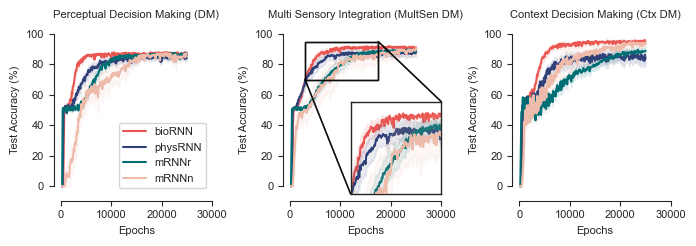

In [66]:

f, ax = plt.subplots(1, n_tasks, figsize=(7, 2.5))

for curve_idx in np.arange(len(curve_details)):
    
    task = curve_details[curve_idx][0]
    kernel_type = curve_details[curve_idx][1]
    decision = curve_details[curve_idx][2]
    reg_weight = curve_details[curve_idx][3]
    n_epochs = curve_details[curve_idx][4]
    n_runs = curve_details[curve_idx][5]
    kernel_label = curve_details[curve_idx][6]
    
    config['reg_weight'] = reg_weight
    config['decision'] = decision
    timing = {'decision': decision}
    env_kwargs = {'dt': dt, 'timing': timing}
    config['env_kwargs'] = env_kwargs
    config['n_runs'] = n_runs
    config['n_epochs'] = n_epochs
    
    i = 0
    for task_name in task_names:
        if task == task_name:
            break
        else:
            i += 1
    # print(task + '  ' + str(i))
    
    j = 0
    for label in kernel_labels:
        if kernel_label == label:
            break
        else:
            j += 1
    # print(kernel_label + '  ' + str(j))
    
    if task == 'PerceptualDecisionMaking-v0':
        seq_len = 22
    elif task == 'MultiSensoryIntegration-v0':
        seq_len = 11
    elif task == 'ContextDecisionMaking-v0':
        seq_len = 13

    seq_len = seq_len + int((decision - 100) / dt)
    seq_len = seq_len * seq_len_multi

    config['task'] = task
    config['seq_len'] = seq_len
    config['kernel_type'] = kernel_type

    # load data
    file_str = get_file_str(config)
    print(file_str)
    try:
        log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
        test_accuracy = log_args['test_accuracy'][:, 1:] * 100
        # test_accuracy = log_args['test_accuracy'][:, 1:151] * 100
        # test_accuracy = log_args['test_accuracy'][:, 1:201] * 100
        # test_accuracy = log_args['test_accuracy'][:, 1:251] * 100

        n_epochs_actual = test_accuracy.shape[1] * 100
        n_logged_epochs = int(n_epochs_actual / 100)
        x_step = int(n_epochs_actual / (n_logged_epochs))
        x = np.arange(x_step, n_epochs_actual + x_step, x_step)

        # compute mean and ci
        accuracy_mean = test_accuracy.mean(axis=0)
        accuracy_std = test_accuracy.std(axis=0)
        ci = 1.96 * (accuracy_std / np.sqrt(test_accuracy.shape[0]))
        ci_lower = accuracy_mean - ci
        ci_upper = accuracy_mean + ci

        ax[i].plot(x, accuracy_mean, color=color_palette[j], label=str(kernel_label))
        ax[i].fill_between(x, ci_lower, ci_upper, color=color_palette[j], alpha=0.1)

        # inset axis
        if task == 'MultiSensoryIntegration-v0':
            x1, x2, y1, y2 = 3000, 17500, 70, 95
            axins = ax[i].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
            axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean[int(x1/100)-1:int(x2/100)-1], color=color_palette[j])
            axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[j], alpha=0.1)
            axins.patch.set_alpha(0)
            ax[i].indicate_inset_zoom(axins, edgecolor="black")
    except:
        print('file not found')

for i in np.arange(n_tasks):
    ax[i].set_xlabel('Epochs')
    if i == 0: ax[i].set_ylabel('Test Accuracy (%)')
    ax[i].set_xlim([0, 30000])
    ax[i].set_ylim([-5, 105])
    ax[i].set_xticks(np.arange(0,30000+1,10000))
    ax[i].set_yticks(np.arange(0,100+1,20))
    ax[i].tick_params(bottom=True,left=True)
    # ax[i].set_ylim([50, 105])
    if i == 0:
        ax[i].legend(loc='lower right')
    ax[i].set_title(tasks_labels[i], fontsize=8)

sns.despine(offset=5, trim=True, left=False, right=True, top=True, bottom=False)

# file_str = '-'.join(file_str.split('-')[:-1])
# f.suptitle(file_str)
f.tight_layout()
plt.show()

if save_figs:
    try:
        file_str = 'accuracy_r{:}_d{:}.svg'.format(str(reg_weight).split('.')[1], decision)
    except:
        file_str = 'accuracy_r{:}_d{:}.svg'.format(reg_weight, decision)
    f.savefig(os.path.join(outdir, file_str), dpi=300, bbox_inches='tight', pad_inches=0.01)